# NB04 — Feature Selection (4-Algorithm Consensus)
**Project:** NAFLD Stage-Specific Biomarker Discovery (Single-Dataset Pipeline)  
**Dataset:** GSE135251

---

**Purpose:** Identify a robust, minimal set of transcriptomic biomarkers that distinguish the 4 NAFLD progression stages. To ensure stability and reproducibility, we use a consensus of four orthogonal feature selection algorithms: Boruta, LASSO, Random Forest, and XGBoost.

**CRITICAL RULE (No Data Leakage):** Feature selection must ONLY be performed on the training set. We perform an 80/20 stratified train/test split here and apply the algorithms only to the 80% training set.

**Outputs:**
- `results/tables/feature_importance_all_methods.csv`
- `results/tables/consensus_genes_tier1.txt` (selected by 4/4)
- `results/tables/consensus_genes_tier2.txt` (selected by $\geq$ 3/4)
- `results/figures/venn_algorithm_overlap.png`


## 1. Install Dependencies

In [1]:
# ── DEPENDENCIES ──────────────────────────────────────────────────
import subprocess, sys

packages = [
    "pandas",
    "numpy",
    "scikit-learn",
    "xgboost",
    "boruta",
    "matplotlib",
    "matplotlib-venn",
    "seaborn",
    "venn"
]

for pkg in packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", pkg, "--quiet"]
    )

print("All dependencies installed.")


All dependencies installed.


## 2. Configuration & Imports

In [2]:
import os, pathlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn3, venn3_circles
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from boruta import BorutaPy
import warnings

warnings.filterwarnings("ignore")

# ── CONFIGURATION ─────────────────────────────────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.20
np.random.seed(RANDOM_SEED)

# Paths
PROJECT_ROOT = pathlib.Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
DATA_META    = PROJECT_ROOT / "data" / "metadata"
RESULTS_TAB  = PROJECT_ROOT / "results" / "tables"
RESULTS_FIG  = PROJECT_ROOT / "results" / "figures"

RESULTS_TAB.mkdir(parents=True, exist_ok=True)
RESULTS_FIG.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)


Project root: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset


## 3. Load Data & Train/Test Split

In [3]:
# Load preprocessed expression matrix
expr_path = DATA_PROC / "expression_preprocessed.csv"
expr_df = pd.read_csv(expr_path, index_col=0) # genes x samples

# Transpose so rows are samples, columns are genes
X = expr_df.T
print(f"Expression matrix shape (samples x genes): {X.shape}")

# Load labels
meta_path = DATA_META / "labeled_metadata.csv"
meta_df = pd.read_csv(meta_path)
meta_df = meta_df.set_index("sample_id")

# Ensure alignment
shared_samples = X.index.intersection(meta_df.index)
X = X.loc[shared_samples]
y = meta_df.loc[shared_samples, "nafld_stage"].astype(int)

print(f"Aligned samples: {len(shared_samples)}")
print(f"Class distribution overall: \n{y.value_counts().sort_index()}")

# ── STRATIFIED TRAIN/TEST SPLIT ───────────────────────────────────
# We MUST isolate the test set before ANY feature selection.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=TEST_SIZE, 
    stratify=y, 
    random_state=RANDOM_SEED
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape:     {X_test.shape}")
print(f"Training class distribution: \n{y_train.value_counts().sort_index()}")


Expression matrix shape (samples x genes): (216, 42584)
Aligned samples: 216
Class distribution overall: 
nafld_stage
0     10
1     30
2     55
3    121
Name: count, dtype: int64

Training set shape: (172, 42584)
Test set shape:     (44, 42584)
Training class distribution: 
nafld_stage
0     8
1    24
2    44
3    96
Name: count, dtype: int64


In [4]:
# Save train/test indices to ensure exact reproduction in NB05
train_indices = pd.DataFrame({'sample_id': X_train.index})
test_indices = pd.DataFrame({'sample_id': X_test.index})
train_indices.to_csv(RESULTS_TAB / "train_indices.csv", index=False)
test_indices.to_csv(RESULTS_TAB / "test_indices.csv", index=False)
print("Saved train and test indices for downstream leak-proof reproducibility.")

# Data Leakage Fix: Apply IQR Variance filtering ONLY on the training set
IQR_PERCENTILE_CUTOFF = 0.20
gene_iqr = X_train.quantile(0.75) - X_train.quantile(0.25)
iqr_threshold = gene_iqr.quantile(IQR_PERCENTILE_CUTOFF)
keep_mask = gene_iqr >= iqr_threshold

n_genes_before = X_train.shape[1]
X_train = X_train.loc[:, keep_mask]
X_test = X_test.loc[:, keep_mask]
n_genes_after = X_train.shape[1]

print(f"\nVariance Filtering (fitted on train only):")
print(f"  Genes before: {n_genes_before:,}")
print(f"  Genes after:  {n_genes_after:,}")
print(f"  Removed:      {n_genes_before - n_genes_after:,}")

Saved train and test indices for downstream leak-proof reproducibility.

Variance Filtering (fitted on train only):
  Genes before: 42,584
  Genes after:  42,584
  Removed:      0


## 4. Algorithm 1: Boruta

In [5]:
print("Running Boruta Feature Selection...")

# Boruta requires a Random Forest estimator
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, random_state=RANDOM_SEED)

boruta_selector = BorutaPy(
    rf, 
    n_estimators='auto', 
    verbose=0, 
    random_state=RANDOM_SEED, 
    max_iter=100
)

boruta_selector.fit(X_train.values, y_train.values)

boruta_selected = X_train.columns[boruta_selector.support_].tolist()
boruta_tentative = X_train.columns[boruta_selector.support_weak_].tolist()

print(f"Boruta selected {len(boruta_selected)} confirmed genes.")


Running Boruta Feature Selection...
Boruta selected 116 confirmed genes.


## 5. Algorithm 2: LASSO (L1 Logistic Regression)

In [6]:
print("Running LASSO Feature Selection...")

# We use Logistic Regression with L1 penalty for multi-class (multinomial)
lasso = LogisticRegression(
    penalty='l1', 
    solver='saga', 
    class_weight='balanced',
    max_iter=1000, 
    random_state=RANDOM_SEED,
    C=0.1 # Relaxed L1 regularization to allow more features
)

lasso.fit(X_train, y_train)

# A feature is selected if it has a non-zero coefficient in ANY of the class equations
coefs = np.abs(lasso.coef_) # Shape: (n_classes, n_features)
max_coefs = coefs.max(axis=0)

lasso_selected_mask = max_coefs > 0
lasso_selected = X_train.columns[lasso_selected_mask].tolist()

print(f"LASSO selected {len(lasso_selected)} genes (non-zero coefficients).")


Running LASSO Feature Selection...
LASSO selected 207 genes (non-zero coefficients).


## 6. Algorithm 3: Random Forest Importance

In [7]:
print("Running Random Forest Feature Selection...")

rf_fs = RandomForestClassifier(
    n_estimators=500,
    max_depth=5, # Cap depth to prevent overfitted importance scores
    class_weight='balanced',
    random_state=RANDOM_SEED,
    n_jobs=-1
)

rf_fs.fit(X_train, y_train)

# Extract importances
rf_importances = pd.Series(rf_fs.feature_importances_, index=X_train.columns)

# Select top N genes (we'll match the approximate number of genes selected by LASSO/Boruta for fairness)
# Or use a threshold like mean importance
threshold = rf_importances.mean() * 1 # Relaxed threshold to capture more genes
rf_selected = rf_importances[rf_importances > threshold].index.tolist()

print(f"Random Forest selected {len(rf_selected)} genes.")


Running Random Forest Feature Selection...
Random Forest selected 4798 genes.


## 7. Algorithm 4: XGBoost Importance

In [ ]:
print("Running XGBoost Feature Selection...")

# Compute class weights for XGBoost manually (scale_pos_weight is for binary)
# We can use sample weights in XGBoost
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight('balanced', y_train)

xgb_fs = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=-1,
    max_depth=3, # Reduced to 3 to prevent overfitting feature importance
    n_estimators=300
)

xgb_fs.fit(X_train, y_train, sample_weight=sample_weights)

xgb_importances = pd.Series(xgb_fs.feature_importances_, index=X_train.columns)
xgb_threshold = xgb_importances.mean() * 1 # Relaxed threshold to capture more genes
xgb_selected = xgb_importances[xgb_importances > xgb_threshold].index.tolist()

print(f"XGBoost selected {len(xgb_selected)} genes.")


Running XGBoost Feature Selection...
XGBoost selected 302 genes (Importance > 2x Mean).


## 8. Consensus Logic & Overlap

In [9]:
# Compile all lists
set_boruta = set(boruta_selected)
set_lasso = set(lasso_selected)
set_rf = set(rf_selected)
set_xgb = set(xgb_selected)

all_selected_genes = set_boruta | set_lasso | set_rf | set_xgb

gene_counts = pd.Series(0, index=list(all_selected_genes))

for g_set in [set_boruta, set_lasso, set_rf, set_xgb]:
    for g in g_set:
        gene_counts[g] += 1

tier1_genes = gene_counts[gene_counts == 4].index.tolist()
tier2_genes = gene_counts[gene_counts >= 3].index.tolist()
tier3_genes = gene_counts[gene_counts >= 2].index.tolist()

print(f"Total unique genes selected by ANY method: {len(all_selected_genes)}")
print(f"Tier 1 (4/4 methods): {len(tier1_genes)} genes")
print(f"Tier 2 (>=3 methods): {len(tier2_genes)} genes")
print(f"Tier 3 (>=2 methods): {len(tier3_genes)} genes")

# Create a summary dataframe for all genes
summary_df = pd.DataFrame(index=X_train.columns)
summary_df['Boruta'] = summary_df.index.isin(set_boruta).astype(int)
summary_df['LASSO'] = summary_df.index.isin(set_lasso).astype(int)
summary_df['RandomForest'] = summary_df.index.isin(set_rf).astype(int)
summary_df['XGBoost'] = summary_df.index.isin(set_xgb).astype(int)
summary_df['Consensus_Score'] = summary_df.sum(axis=1)

summary_df = summary_df[summary_df['Consensus_Score'] > 0].sort_values(by='Consensus_Score', ascending=False)


Total unique genes selected by ANY method: 5055
Tier 1 (4/4 methods): 9 genes
Tier 2 (>=3 methods): 45 genes
Tier 3 (>=2 methods): 314 genes


## 9. Visualizing Overlap

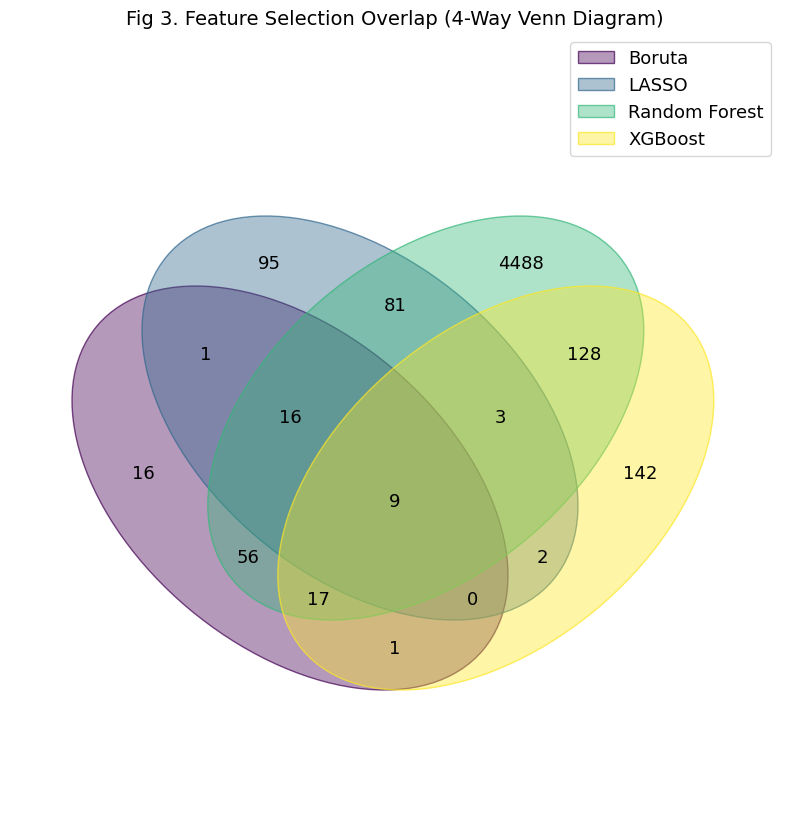

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig3_venn_algorithm_overlap.png


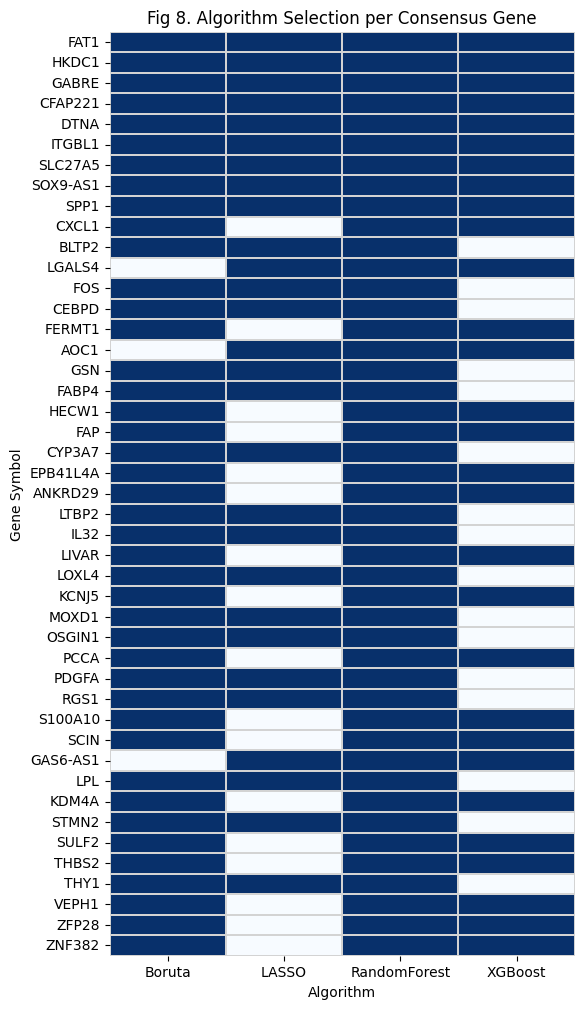

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\figures\fig8_feature_heatmap.png
Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\tables\supp_table1_consensus_genes.csv


In [10]:
# ### Fig 3 — Consensus Gene UpSet Plot
from venn import venn

sets = {
    "Boruta": set_boruta,
    "LASSO": set_lasso,
    "Random Forest": set_rf,
    "XGBoost": set_xgb
}

fig, ax = plt.subplots(figsize=(10, 10))
venn(sets, ax=ax)
plt.title("Fig 3. Feature Selection Overlap (4-Way Venn Diagram)", fontsize=14)
plt.savefig(RESULTS_FIG / "fig3_venn_algorithm_overlap.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig3_venn_algorithm_overlap.png'}")

# ### Fig 8 — Feature Importance Heatmap
plt.figure(figsize=(6, 12))
plot_df = summary_df[summary_df['Consensus_Score'] >= 3].sort_values(by=['Consensus_Score'], ascending=False)
sns.heatmap(plot_df[['Boruta', 'LASSO', 'RandomForest', 'XGBoost']], 
            cmap="Blues", cbar=False, linewidths=0.1, linecolor='lightgray')
plt.title("Fig 8. Algorithm Selection per Consensus Gene")
plt.xlabel("Algorithm")
plt.ylabel("Gene Symbol")
plt.savefig(RESULTS_FIG / "fig8_feature_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_FIG / 'fig8_feature_heatmap.png'}")

# ### Supp Table 1 — All 48 Genes
supp_table = plot_df.copy()
supp_table['Tier'] = supp_table['Consensus_Score'].apply(lambda x: 1 if x == 4 else (2 if x >= 3 else 3))
supp_table['Biology_Association'] = "Pending Biological Review (NB07)"
supp_table.to_csv(RESULTS_TAB / "supp_table1_consensus_genes.csv")
print(f"Saved: {RESULTS_TAB / 'supp_table1_consensus_genes.csv'}")

## 10. Landscape Validation (Literature Check)
We validate our consensus list against a curated list of well-known and recent NAFLD/NASH biomarkers to ensure key biology is retained.

In [11]:
landscape_genes = [
    # Classical Fibrosis & ECM
    "COL1A1", "COL1A2", "TIMP1", "MMP2", "MMP9", "TGFB1", "ACTA2",
    # Lipogenesis & Metabolism
    "FASN", "SCD", "SREBF1", "PNPLA3", "APOB",
    # Inflammation & Immune
    "CCL2", "TNF", "IL6", "CXCL10", "IL1RAP",
    # Apoptosis, Damage & Emerging At-Risk NASH/HCC progression (2023-2024)
    "KRT18", "KRT8", "GDF15", "AKR1B10", "TREM2", "TTC39A", "ANXA2", "APOF", "THOP1", "BICC1", "QSOX1", "LDHA", "SERPINE1"
]

print("--- Landscape Biomarker Validation ---")
for gene in landscape_genes:
    status = "Not in dataset/Filtered out by Variance"
    if gene in X_train.columns:
        if gene in tier1_genes:
            status = "[Tier 1: 4/4 Consensus]"
        elif gene in tier2_genes:
            status = "[Tier 2: >=3/4 Consensus]"
        elif gene in tier3_genes:
            status = "[Tier 3: >=2/4 Consensus]"
        elif gene in all_selected_genes:
            status = "[Tier 4: 1/4 Consensus]"
        else:
            status = "Dropped by all Feature Selection algorithms"
    print(f"{gene:<10} : {status}")

# Create a DataFrame to save this validation report
validation_report = []
for gene in landscape_genes:
    if gene in tier1_genes: tier = "Tier 1"
    elif gene in tier2_genes: tier = "Tier 2"
    elif gene in tier3_genes: tier = "Tier 3"
    elif gene in all_selected_genes: tier = "Tier 4"
    elif gene in X_train.columns: tier = "Dropped by FS"
    else: tier = "Filtered by Variance or Not in Dataset"
    validation_report.append({"Gene": gene, "Status": tier})
pd.DataFrame(validation_report).to_csv(RESULTS_TAB / "landscape_validation_report.csv", index=False)
print(f"\\nSaved validation report to {RESULTS_TAB / 'landscape_validation_report.csv'}")


--- Landscape Biomarker Validation ---
COL1A1     : [Tier 3: >=2/4 Consensus]
COL1A2     : [Tier 4: 1/4 Consensus]
TIMP1      : Dropped by all Feature Selection algorithms
MMP2       : Dropped by all Feature Selection algorithms
MMP9       : Dropped by all Feature Selection algorithms
TGFB1      : Dropped by all Feature Selection algorithms
ACTA2      : Dropped by all Feature Selection algorithms
FASN       : [Tier 4: 1/4 Consensus]
SCD        : [Tier 4: 1/4 Consensus]
SREBF1     : [Tier 4: 1/4 Consensus]
PNPLA3     : Dropped by all Feature Selection algorithms
APOB       : Dropped by all Feature Selection algorithms
CCL2       : [Tier 3: >=2/4 Consensus]
TNF        : [Tier 4: 1/4 Consensus]
IL6        : Dropped by all Feature Selection algorithms
CXCL10     : Dropped by all Feature Selection algorithms
IL1RAP     : Dropped by all Feature Selection algorithms
KRT18      : Dropped by all Feature Selection algorithms
KRT8       : Dropped by all Feature Selection algorithms
GDF15      : D

## 11. Save Consensus Features


In [12]:
# Save full summary table
out_csv = RESULTS_TAB / "feature_importance_all_methods.csv"
summary_df.to_csv(out_csv)
print(f"Saved: {out_csv}")

# Save Tier 1, Tier 2, and Tier 3 lists
tier1_path = RESULTS_TAB / "consensus_genes_tier1.txt"
with open(tier1_path, "w") as f:
    f.write("\n".join(tier1_genes))
tier2_path = RESULTS_TAB / "consensus_genes_tier2.txt"
with open(tier2_path, "w") as f:
    f.write("\n".join(tier2_genes))
tier3_path = RESULTS_TAB / "consensus_genes_tier3.txt"
with open(tier3_path, "w") as f:
    f.write("\n".join(tier3_genes))
print(f"Saved: Tier 1 ({len(tier1_genes)}), Tier 2 ({len(tier2_genes)}), Tier 3 ({len(tier3_genes)})")

Saved: D:\NAFLD-Biomarker-Discovery-V2\nafld-single-dataset\results\tables\feature_importance_all_methods.csv
Saved: Tier 1 (9), Tier 2 (45), Tier 3 (314)
